# Etapa 1 - Analiza datelor de intrare

In aceasta parte a proiectului analizam datele procesate anterior. Scopul este sa intelegem structura CV-urilor, cate skill-uri au fost extrase si care sunt cele mai frecvente competente identificate.

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import ast

## Incarcarea datelor procesate

Incarcam fisierul CSV generat dupa curatarea CV-urilor si extragerea skill-urilor.

In [9]:
df = pd.read_csv("processed_resumes.csv")

df.head()

,resume_text,clean_resume,skills_found,num_skills
0,"{""name"":""Unknown"",""email"":""Unknown"",""phone"":""U...",name unknown email unknown phone unknown locat...,"['python', 'c++', 'sql', 'mysql', 'tensorflow'...",7
1,"{""name"":""Unknown"",""email"":""Unknown"",""phone"":""U...",name unknown email unknown phone unknown locat...,[],0
2,"{""name"":""Not Provided"",""email"":""Not Provided"",...",name not provided email not provided phone not...,"['git', 'github']",2
3,"{""name"":""Unknown"",""email"":""Unknown"",""phone"":""U...",name unknown email unknown phone unknown locat...,[],0
4,"{""name"":"""",""email"":"""",""phone"":"""",""location"":{""...",name email phone location city pune country in...,"['git', 'github']",2


## Informatii generale despre dataset

Verificam numarul de CV-uri, coloanele existente si daca exista valori lipsa.

In [10]:
print("Numar CV-uri:", len(df))
print("Coloane:", df.columns.tolist())
print(df.isnull().sum())

Numar CV-uri: 1000
Coloane: ['resume_text', 'clean_resume', 'skills_found', 'num_skills']
resume_text     1
clean_resume    1
skills_found    0
num_skills      0
dtype: int64


## Analiza numarului de skill-uri

Analizam cate skill-uri au fost gasite in fiecare CV.

In [11]:
print("Numar mediu skill-uri:", df["num_skills"].mean())
print("Numar maxim skill-uri:", df["num_skills"].max())
print("Numar minim skill-uri:", df["num_skills"].min())

Numar mediu skill-uri: 2.909
Numar maxim skill-uri: 8
Numar minim skill-uri: 0


## Grafic: distributia numarului de skill-uri

Acest grafic arata cate CV-uri au 0, 1, 2 sau mai multe skill-uri detectate.

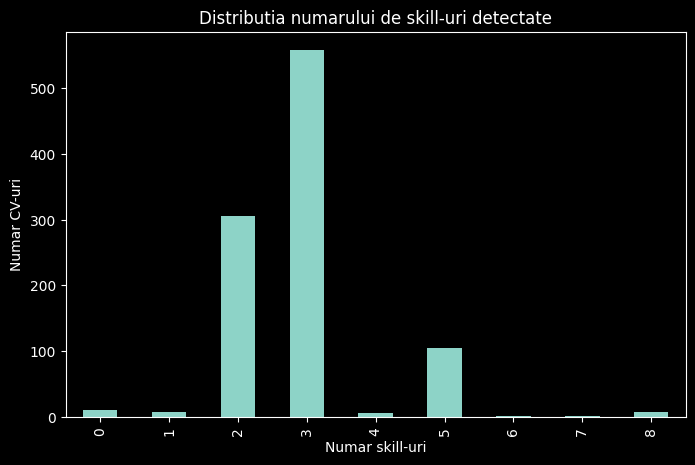

In [12]:
plt.figure(figsize=(8, 5))
df["num_skills"].value_counts().sort_index().plot(kind="bar")
plt.title("Distributia numarului de skill-uri detectate")
plt.xlabel("Numar skill-uri")
plt.ylabel("Numar CV-uri")
plt.show()

## Top skill-uri identificate

Transformam coloana cu skill-uri intr-o lista si calculam cele mai frecvente competente.

In [13]:
all_skills = []

for skills in df["skills_found"]:
    try:
        skills_list = ast.literal_eval(skills)
        all_skills.extend(skills_list)
    except:
        pass

skill_counts = Counter(all_skills)

top_skills = pd.DataFrame(
    skill_counts.items(),
    columns=["skill", "count"]
).sort_values(by="count", ascending=False)

top_skills.head(10)

,skill,count
6,github,982
5,git,982
7,java,239
0,python,234
16,react,200
10,javascript,106
17,docker,83
2,sql,15
11,machine learning,14
3,mysql,13


## Grafic: cele mai frecvente skill-uri

Acest grafic arata skill-urile care apar cel mai des in CV-urile analizate.

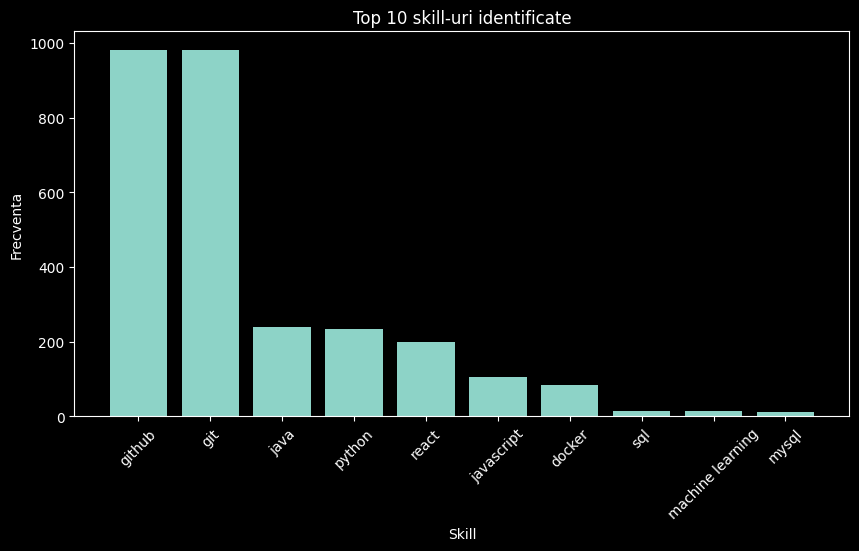

In [14]:
plt.figure(figsize=(10, 5))
plt.bar(top_skills["skill"].head(10), top_skills["count"].head(10))
plt.title("Top 10 skill-uri identificate")
plt.xlabel("Skill")
plt.ylabel("Frecventa")
plt.xticks(rotation=45)
plt.show()

## Analiza rezultatelor de matching

Dupa ce au fost calculate scorurile de potrivire dintre CV-uri si job descriptions, analizam rezultatele pentru a vedea cat de bine se potrivesc candidatii cu cerintele joburilor.

In [15]:
matching_df = pd.read_csv("matching_results.csv")

matching_df.head()

,job_id,candidate_id,job_description,match_score,matched_skills,missing_skills
0,0,0,We are looking for a Python developer with SQL...,75.0,"['sql', 'python', 'git']",['machine learning']
1,0,1,We are looking for a Python developer with SQL...,0.0,[],"['machine learning', 'sql', 'python', 'git']"
2,0,2,We are looking for a Python developer with SQL...,25.0,['git'],"['machine learning', 'sql', 'python']"
3,0,3,We are looking for a Python developer with SQL...,0.0,[],"['machine learning', 'sql', 'python', 'git']"
4,0,4,We are looking for a Python developer with SQL...,25.0,['git'],"['machine learning', 'sql', 'python']"


## Statistici generale pentru scorurile de potrivire

In [16]:
print("Numar total matching-uri:", len(matching_df))
print("Scor mediu:", matching_df["match_score"].mean())
print("Scor maxim:", matching_df["match_score"].max())
print("Scor minim:", matching_df["match_score"].min())

Numar total matching-uri: 8000
Scor mediu: 9.950077499999999
Scor maxim: 100.0
Scor minim: 0.0


## Distributia scorurilor de potrivire

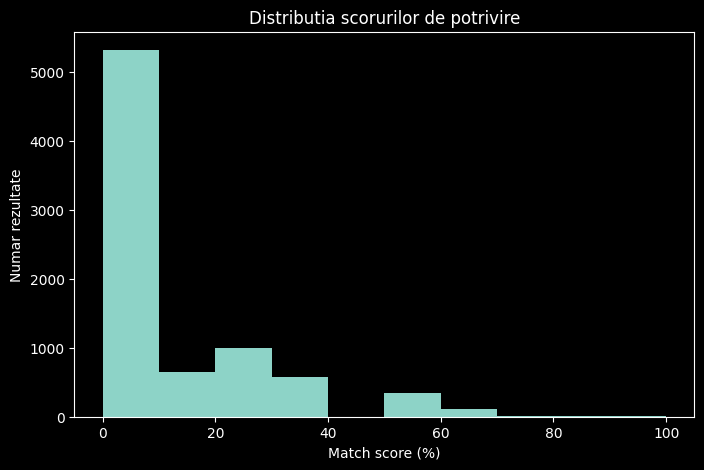

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(matching_df["match_score"], bins=10)
plt.title("Distributia scorurilor de potrivire")
plt.xlabel("Match score (%)")
plt.ylabel("Numar rezultate")
plt.show()

## Scor mediu pe fiecare job

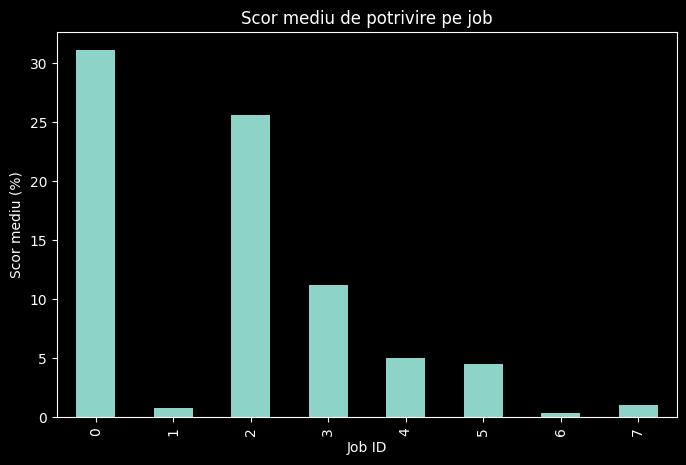

In [18]:
avg_scores = matching_df.groupby("job_id")["match_score"].mean()

plt.figure(figsize=(8, 5))
avg_scores.plot(kind="bar")
plt.title("Scor mediu de potrivire pe job")
plt.xlabel("Job ID")
plt.ylabel("Scor mediu (%)")
plt.show()

## Top candidati dupa scor

In [19]:
top_matches = matching_df.sort_values(by="match_score", ascending=False).head(10)

top_matches[[
    "job_id",
    "candidate_id",
    "match_score",
    "matched_skills",
    "missing_skills"
]]

,job_id,candidate_id,match_score,matched_skills,missing_skills
6211,6,211,100.00,['c++'],[]
6000,6,0,100.00,['c++'],[]
6124,6,124,100.00,['c++'],[]
124,0,124,100.00,"['machine learning', 'sql', 'python', 'git']",[]
2087,2,87,83.33,"['java', 'css', 'html', 'javascript', 'git']",['react']
2066,2,66,83.33,"['java', 'css', 'html', 'javascript', 'git']",['react']
2035,2,35,83.33,"['java', 'css', 'html', 'javascript', 'git']",['react']
2007,2,7,83.33,"['java', 'css', 'html', 'javascript', 'git']",['react']
0,0,0,75.00,"['sql', 'python', 'git']",['machine learning']
65,0,65,75.00,"['sql', 'python', 'git']",['machine learning']
